In [1]:

import polars as pl
from sklearn.metrics import accuracy_score

from autotsc.utils import load_dataset
from time import perf_counter

import numpy as np
import polars as pl
import ray
from aeon.classification.dictionary_based import REDCOMETS
from aeon.classification.interval_based import SupervisedTimeSeriesForest

from aeon.classification.base import BaseClassifier
from aeon.classification.convolution_based import (
    MiniRocketClassifier,
    MultiRocketClassifier,
    RocketClassifier,
)
from aeon.classification.dummy import DummyClassifier
from aeon.classification.feature_based import (
    Catch22Classifier,
    SummaryClassifier,
)
from aeon.classification.interval_based import (
    QUANTClassifier,
)
from aeon.classification.sklearn import SklearnClassifierWrapper
from aeon.pipeline import make_pipeline as aeon_make_pipeline
from aeon.transformations.collection import DownsampleTransformer
from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
import types
from autotsc.models import RidgeClassifierCVWithProba
from aeon.classification.convolution_based import HydraClassifier
from autotsc import transformers, utils
from aeon.classification.dictionary_based import IndividualBOSS
from aeon.classification.interval_based import (
    RSTSF,
    CanonicalIntervalForestClassifier,
    DrCIFClassifier,
    QUANTClassifier,
    RandomIntervalSpectralEnsembleClassifier,
    SupervisedTimeSeriesForest,
    TimeSeriesForestClassifier,
)
from aeon.classification.interval_based import RSTSF
from aeon.classification.dictionary_based import WEASEL_V2



2025-11-18 16:06:18.577326: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
!uv pip install catboost

Audited 1 package in 22ms


In [3]:
from sklearn.model_selection import StratifiedKFold

def get_folds(X, y, n_splits=10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True)
    folds = []
    for train_idx, val_idx in skf.split(X, y):
        folds.append((train_idx.tolist(), val_idx.tolist()))
    return folds

In [4]:
X_train, y_train, X_test, y_test = load_dataset("CricketZ")
X_train, y_train, X_test, y_test = load_dataset("MelbournePedestrian")
X_train, y_train, X_test, y_test = load_dataset("Worms")
X_train, y_train, X_test, y_test = load_dataset("PhalangesOutlinesCorrect")


In [5]:
class CVWrapper(BaseClassifier):
    def __init__(self, model):
        self.model = model
        self.models = []
        self.classes_ = None
        super().__init__()

    def _fit(self, X, y):
        return self

    def _predict(self, X):
        predictions = np.array([model.predict_proba(X) for model in self.models])
        avg_proba = predictions.mean(axis=0)
        predicted_indices = np.argmax(avg_proba, axis=1)
        return self.classes_[predicted_indices]
    
    def fit_predict_proba_cv(self, X, y, cv_splits):
        self.fit(X, y)
        proba_predictions = []
        for train_idx, val_idx in cv_splits:
            model_clone = clone(self.model)
            model_clone.fit(X[train_idx], y[train_idx])
            self.classes_ = model_clone.classes_
            self.models.append(model_clone)
            y_proba = model_clone.predict_proba(X[val_idx])
            proba_predictions.extend(zip(val_idx, y_proba))
        proba_predictions = sorted(proba_predictions)
        return np.array([proba for idx, proba in proba_predictions])

    def fit_predict_cv(self, X, y, cv_splits):
        self.fit(X, y)
        predictions = []
        for train_idx, val_idx in cv_splits:
            model_clone = clone(self.model)
            model_clone.fit(X[train_idx], y[train_idx])
            self.classes_ = model_clone.classes_
            self.models.append(model_clone)
            y_pred = model_clone.predict(X[val_idx])
            predictions.extend(zip(val_idx, y_pred))
        predictions = sorted(predictions)
        return [pred for idx, pred in predictions]
    
class Ensemble:
    def __init__(self, model):
        self.model_ = model
        self.models = []

    def fit_predict_proba_cv(self, X, y, cv_splits):
        proba_predictions = []
        for train_idx, val_idx in cv_splits:
            model_clone = clone(self.model_)
            model_clone.fit(X[train_idx], y[train_idx])
            self.models.append(model_clone)
            y_proba = model_clone.predict_proba(X[val_idx])
            proba_predictions.extend(zip(val_idx, y_proba))
        proba_predictions = sorted(proba_predictions)
        return np.array([proba for idx, proba in proba_predictions])
    
    def predict(self, X):
        predictions = np.array([model.predict_proba(X) for model in self.models])
        avg_proba = predictions.mean(axis=0)
        predicted_indices = np.argmax(avg_proba, axis=1)
        return self.models[0].classes_[predicted_indices]

In [6]:
class EnsambleWeights:
    def __init__(self):
        pass

In [7]:
class AutoTSCModel(BaseClassifier):

    # TODO: change capability tags
    _tags = {
        "capability:multivariate": True,
        "capability:train_estimate": True,
        "capability:contractable": True,
        "capability:multithreading": True,
        "algorithm_type": "convolution",
    }

    def __init__(self):
        self.models_ = []
        self.meta_models_ = []
        self.summary_ = []
        self.oof_predictions_ = None
        self.verbose = 1
        self.n_jobs = -1
        self.n_gpus = -1
        super().__init__()

    def get_default_models(self):
        model1 = CVWrapper(
            RocketClassifier(n_jobs=-1, estimator=RidgeClassifierCVWithProba(alphas=np.logspace(-3, 3, 10)), random_state=41)
        )
        model2 = CVWrapper(Catch22Classifier(n_jobs=-1))
        model3 = CVWrapper(
            MiniRocketClassifier(n_jobs=-1, estimator=RidgeClassifierCVWithProba(alphas=np.logspace(-3, 3, 10)), random_state=41)
        )
        model4 = CVWrapper(
            QUANTClassifier(random_state=42)
        )
        model5 = CVWrapper(
            HydraClassifier(n_jobs=-1, random_state=42)
        )
        model6 = CVWrapper(
            IndividualBOSS(n_jobs=-1, random_state=42)
        )
        model7 = CVWrapper(
            DrCIFClassifier(n_jobs=-1, random_state=42, n_estimators=5)
        )
        model8 = CVWrapper(
            REDCOMETS(n_jobs=-1, n_trees=200)
        )
        model9 = CVWrapper(
            RSTSF(n_jobs=-1)
        )
        model10 = CVWrapper(
            WEASEL_V2(n_jobs=-1, max_feature_count=10000)
        )
        model11 = CVWrapper(
            SupervisedTimeSeriesForest(n_jobs=-1, n_estimators=20)
        )
        model12 = CVWrapper(
            MultiRocketClassifier(n_jobs=-1, estimator=RidgeClassifierCVWithProba(alphas=np.logspace(-3, 3, 10)), random_state=41)
        )
        return [model1, model2, model3, model4, model5, model6, model7, model8, model9, model10, model11, model12]

    def get_default_metamodels(self):
        model1 = Ensemble(RidgeClassifierCVWithProba(alphas=np.logspace(-3, 3, 10)))
        model2 = Ensemble(RandomForestClassifier(n_jobs=-1, n_estimators=100))
        model3 = Ensemble(HistGradientBoostingClassifier())
        model4 = Ensemble(ExtraTreesClassifier(n_jobs=-1, n_estimators=100))
        model5 = Ensemble(RandomForestClassifier(n_jobs=-1, n_estimators=100, ccp_alpha=0.01))
        # add catboost
        from catboost import CatBoostClassifier
        model6 = Ensemble(
            CatBoostClassifier()
        )
        return [model1, model2, model3, model4, model5, model6]

    def _fit(self, X, y):
        self.cpus_available_, self.cpus_to_use_, self.gpus_available_, self.gpus_to_use_ = (
            utils.get_resource_config(self.n_jobs, self.n_gpus)
        )
        if self.verbose > 0:
            utils.print_fit_start_info(
                X,
                y,
                self.cpus_to_use_,
                self.cpus_available_,
                self.gpus_to_use_,
                self.gpus_available_,
            )
        folds = get_folds(X, y, n_splits=16)
        default_models = self.get_default_models()
        for model_id, model in enumerate(default_models):
            start_time = perf_counter()
            pred = model.fit_predict_proba_cv(X, y, folds)
            stop_time = perf_counter()
            self.models_.append(model)
            # take argmax and compute accuracy. use .classes_ to map back to original labels
            pred_max = np.argmax(pred, axis=1)
            acc = accuracy_score(y, model.classes_[pred_max])
            # acc = accuracy_score(y, pred)
            self.summary_.append({
                "model_id": model_id, 
                "model": repr(model).replace("\n", "").replace(" ", ""),
                "validation_accuracy": acc,
                "stacking_level": 0,
                "train_time": stop_time - start_time,
            })

            if self.verbose > 0:
                print(f"Trained base model {model_id}, OOF accuracy: {acc:.4f}")

            columns = [f'model_{model_id}__class_{l}' for l in list(model.classes_)]
            if self.oof_predictions_ is None:
                self.oof_predictions_ = pl.DataFrame(pred, schema=columns)
            else:
                df_pred = pl.DataFrame(pred, schema=columns)
                self.oof_predictions_ = pl.concat([self.oof_predictions_, df_pred], how='horizontal')

        default_metamodels = self.get_default_metamodels()
        for model_id, model in enumerate(default_metamodels):
            pred = model.fit_predict_proba_cv(self.oof_predictions_.to_numpy(), y, folds)
            pred_max = np.argmax(pred, axis=1)
            acc = accuracy_score(y, model.models[0].classes_[pred_max])
            self.meta_models_.append(model)
            self.summary_.append({
                "model_id": len(default_models) + model_id, 
                "model": repr(model).replace("\n", "").replace(" ", ""),
                "validation_accuracy": acc,
                "stacking_level": 1,
            })

        return self
    
    def summary(self):
        return pl.DataFrame(self.summary_)
    
    def predict_per_model(self, X):
        "make predictions for each model in the ensemble"
        all_preds = {}
        oof_predictions_ = None
        for i, model in enumerate(self.models_):
            pred_probs = model.predict_proba(X)
            columns = [f'model_{i}__class_{l}' for l in list(model.classes_)]
            if oof_predictions_ is None:
                oof_predictions_ = pl.DataFrame(pred_probs, schema=columns)
            else:
                df_pred = pl.DataFrame(pred_probs, schema=columns)
                oof_predictions_ = pl.concat([oof_predictions_, df_pred], how='horizontal')
            pred = np.argmax(pred_probs, axis=1)
            pred_labels = model.classes_[pred]
            all_preds[i] = pred_labels

        for i, model in enumerate(self.meta_models_):
            pred = model.predict(oof_predictions_.to_numpy())
            all_preds[len(self.models_) + i] = pred

        return all_preds

    def _predict(self, X):
        m = self.models_[0]
        return m._predict(X)

folds = get_folds(X_train, y_train, n_splits=10)

In [8]:
model = AutoTSCModel()
model.fit(X_train, y_train)
pred = model.predict(X_test)
accuracy_score(y_test, pred)

|-------------------------|
| Number of samples: 1800 |
| Number of channels: 1   |
| Length of series: 80    |
| Number of classes: 2    |
| CPUs: 24/24             |
| GPUs: 2/2               |
|-------------------------|
Trained base model 0, OOF accuracy: 0.8633
Trained base model 1, OOF accuracy: 0.7978
Trained base model 2, OOF accuracy: 0.8578
Trained base model 3, OOF accuracy: 0.8672
Trained base model 4, OOF accuracy: 0.8594


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/g

Trained base model 5, OOF accuracy: 0.6533
Trained base model 6, OOF accuracy: 0.8094
Trained base model 7, OOF accuracy: 0.8361
Trained base model 8, OOF accuracy: 0.8544
Trained base model 9, OOF accuracy: 0.8628
Trained base model 10, OOF accuracy: 0.8489
Trained base model 11, OOF accuracy: 0.8739
Learning rate set to 0.01288
0:	learn: 0.6805704	total: 48.1ms	remaining: 48.1s
1:	learn: 0.6677568	total: 50.1ms	remaining: 25s
2:	learn: 0.6554740	total: 51.1ms	remaining: 17s
3:	learn: 0.6425709	total: 52ms	remaining: 13s
4:	learn: 0.6306833	total: 53ms	remaining: 10.5s
5:	learn: 0.6191669	total: 53.8ms	remaining: 8.92s
6:	learn: 0.6085776	total: 54.8ms	remaining: 7.77s
7:	learn: 0.5982322	total: 55.6ms	remaining: 6.9s
8:	learn: 0.5889897	total: 56.6ms	remaining: 6.23s
9:	learn: 0.5797561	total: 57.5ms	remaining: 5.7s
10:	learn: 0.5697272	total: 58.6ms	remaining: 5.26s
11:	learn: 0.5603815	total: 59.6ms	remaining: 4.9s
12:	learn: 0.5517164	total: 60.6ms	remaining: 4.6s
13:	learn: 0.542

0.831002331002331

In [9]:
summary = model.summary()

In [10]:
test_accs = []
preds = model.predict_per_model(X_test)
for m, p in preds.items():
    acc = accuracy_score(y_test, p)
    test_accs.append({
        "model_id": m,
        "test_accuracy": acc,
    })
test_accs = pl.DataFrame(test_accs)
summary = summary.join(test_accs, on="model_id")

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/g

In [11]:
summary.sort("validation_accuracy")

model_id,model,validation_accuracy,stacking_level,train_time,test_accuracy
i64,str,f64,i64,f64,f64
5,"""CVWrapper(model=IndividualBOSS…",0.653333,0,3.068302,0.634033
1,"""CVWrapper(model=Catch22Classif…",0.797778,0,27.635012,0.783217
6,"""CVWrapper(model=DrCIFClassifie…",0.809444,0,149.641429,0.819347
7,"""CVWrapper(model=REDCOMETS(n_jo…",0.836111,0,263.92954,0.817016
10,"""CVWrapper(model=SupervisedTime…",0.848889,0,32.09804,0.834499
…,…,…,…,…,…
15,"""<__main__.Ensembleobjectat0x76…",0.873889,1,null,0.853147
17,"""<__main__.Ensembleobjectat0x76…",0.874444,1,null,0.854312
16,"""<__main__.Ensembleobjectat0x76…",0.876111,1,null,0.855478


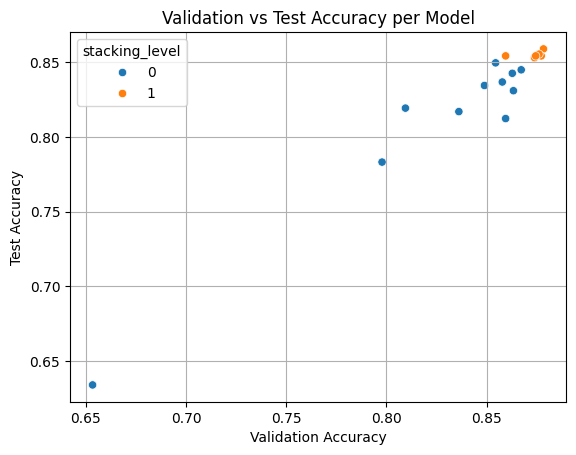

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(data=summary, x="validation_accuracy", y="test_accuracy", hue="stacking_level")
plt.xlabel("Validation Accuracy")
plt.ylabel("Test Accuracy")
plt.title("Validation vs Test Accuracy per Model")
plt.grid(True)

In [13]:
#sns.scatterplot(data=summary.filter(pl.col("stacking_level") == 0), x="validation_accuracy", y="test_accuracy")

In [14]:
model = RocketClassifier(n_jobs=-1, random_state=41)
model.fit(X_train, y_train)
pred = model.predict(X_test)
accuracy_score(y_test, pred)

0.831002331002331

In [15]:
model2 = CVWrapper(
    RocketClassifier(n_jobs=-1, estimator=RidgeClassifierCVWithProba(alphas=np.logspace(-3, 3, 10)), random_state=41)
)
model2.fit_predict_cv(X_train, y_train, folds)
pred2 = model2._predict(X_test)
accuracy_score(y_test, pred2)

0.831002331002331

In [16]:
model2 = CVWrapper(
    RocketClassifier(n_jobs=-1, estimator=RidgeClassifierCVWithProba(alphas=np.logspace(-3, 3, 10)), random_state=41)
)
pp = model2.fit_predict_proba_cv(X_train, y_train, folds)
pred2 = model2._predict(X_test)
accuracy_score(y_test, pred2)

0.831002331002331

In [17]:
pp.shape

(1800, 2)

In [18]:
from aeon.classification.interval_based import (
    RSTSF,
    CanonicalIntervalForestClassifier,
    DrCIFClassifier,
    QUANTClassifier,
    RandomIntervalSpectralEnsembleClassifier,
    SupervisedTimeSeriesForest,
    TimeSeriesForestClassifier,
)
from aeon.classification.shapelet_based import ShapeletTransformClassifier


In [19]:
m = ShapeletTransformClassifier(n_jobs=-1, time_limit_in_minutes=1)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.48717948717948717

In [20]:
m = DrCIFClassifier(n_jobs=-1, time_limit_in_minutes=1)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.8368298368298368

In [21]:
from aeon.classification.dictionary_based import TemporalDictionaryEnsemble
m = TemporalDictionaryEnsemble(n_jobs=-1, time_limit_in_minutes=1)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/numba/typed/typeddict.py:54: NumbaTypeSafetyWarning: unsafe cast from int64 to uint32. Precision may be lost.
  return d.get(key, default)
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/numba/typed/typeddict.py:34: NumbaTypeSafetyWarning: unsafe cast from int64 to uint32. Precision may be lost.
  d[key] = value
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/numba/typed/typeddict.py:54: NumbaTypeSafetyWarning: unsafe cast from int64 to uint32. Precision may be lost.
  return d.get(key, default)


0.7389277389277389

In [22]:
from aeon.classification.convolution_based import Arsenal
m = Arsenal(n_jobs=-1, time_limit_in_minutes=1)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.8275058275058275

In [23]:
from aeon.classification.convolution_based import Arsenal
m = Arsenal(n_jobs=-1, time_limit_in_minutes=1, rocket_transform="multirocket")   
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.8566433566433567

In [24]:
!uv pip install imblearn

Audited 1 package in 4ms


/home/gasper_p/.local/share/uv/python/cpython-3.12.0-linux-x86_64-gnu/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=1923665) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


In [25]:
m = REDCOMETS(n_jobs=-1, n_trees=100)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.8205128205128205

In [26]:
m = RSTSF(n_jobs=-1)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.8508158508158508

In [27]:
from aeon.classification.deep_learning import IndividualLITEClassifier
m = IndividualLITEClassifier(verbose=1, n_epochs=200)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

I0000 00:00:1763480971.115778 1923665 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6029 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:04:00.0, compute capability: 8.6
I0000 00:00:1763480971.116974 1923665 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 6153 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:08:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 80, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-increasse-0… │ (None, 80, 1)     │          2 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-increasse-1… │ (None, 80, 1)     │          4 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-increasse-2… │ (None, 80, 1)     │          8 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-increasse-3… │ (None, 80, 1)     │         16 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-increasse-4… │ (None, 80, 1)     │         32 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-increasse-5… │ (None, 80, 1)     │         64 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-decrease-6-2 │ (None, 80, 1)     │          2 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-decrease-7-4 │ (None, 80, 1)     │          4 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-decrease-8-8 │ (None, 80, 1)     │          8 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-decrease-9-… │ (None, 80, 1)     │         16 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-decrease-10… │ (None, 80, 1)     │         32 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-decrease-11… │ (None, 80, 1)     │         64 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-peeks-12-4   │ (None, 80, 1)     │          6 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-peeks-13-8   │ (None, 80, 1)     │         12 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-peeks-14-16  │ (None, 80, 1)     │         24 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid-peeks-15-32  │ (None, 80, 1)     │         48 │ input_layer[0][0

 Total params: 10,672 (41.69 KB)

 Trainable params: 9,880 (38.59 KB)

 Non-trainable params: 792 (3.09 KB)

Epoch 1/200


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
2025-11-18 16:49:33.131743: I external/local_xla/xla/service/service.cc:163] XLA service 0x76d9280064e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-18 16:49:33.131765: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2025-11-18 16:49:33.131767: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2025-11-18 16:49:33.167626: I tensorflow/compiler/ml

29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - accuracy: 0.5839 - loss: 0.6651 - learning_rate: 0.0010
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6994 - loss: 0.6073 - learning_rate: 0.0010
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7044 - loss: 0.5897 - learning_rate: 0.0010
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7200 - loss: 0.5677 - learning_rate: 0.0010
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7250 - loss: 0.5480 - learning_rate: 0.0010
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7422 - loss: 0.5328 - learning_rate: 0.0010
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7500 - loss: 0.5089 - learning_rate: 0.0010
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7706 - loss: 0.4921 - learning_rate: 0.0010
Epoch 9/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7739 - loss: 0.4884 - learning_rate: 0.0010
Epoch 10/200
29/29 ━━━━━━━━

0.8205128205128205

In [28]:
m = WEASEL_V2(n_jobs=-1, max_feature_count=10000)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.8251748251748252

In [29]:
#from aeon.classification.distance_based import ProximityForest
#m = ProximityForest(n_jobs=-1, n_trees=10, max_depth=5)
#m.fit(X_train, y_train)
#pred = m.predict(X_test)
#accuracy_score(y_test, pred)

In [30]:
from aeon.classification.interval_based import SupervisedTimeSeriesForest
m = SupervisedTimeSeriesForest(n_jobs=-1)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.8391608391608392

In [31]:
m = SupervisedTimeSeriesForest(n_jobs=4, n_estimators=20)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.8321678321678322

In [32]:
X_train, y_train, X_test, y_test = load_dataset("NonInvasiveFetalECGThorax1")
print(X_train.shape, X_test.shape)

(1800, 1, 750) (1965, 1, 750)


In [33]:
m = SupervisedTimeSeriesForest(n_jobs=4, n_estimators=20)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.8941475826972011

In [34]:
m = SupervisedTimeSeriesForest(n_jobs=-1, n_estimators=20)
m.fit(X_train, y_train)
pred = m.predict(X_test)
accuracy_score(y_test, pred)

0.9022900763358779